# Hybrid Self-Supervised CNN Model (ImageNetV1 with Physics-Based Reward Function)

## **Reward Function**
+ **Height Consistency** (Trace vs Retrace) - MAE between two values
+ **Phase Consistency** (Trace vs Retrace) - MSE between values
+ **Image Sharpness/Focus** (using gradient variance, for the CNN's image training)
+ **Signal-to-Noise Ratio of Height** (SNR, for the CNN's features training)
+ **Data Quality** (check for artifacts, clips, or excess saturation)
+ **Scan Index Penalty** (prefer earlier scans, indicating tip quality based on experiment)
+ **Scan Rate Appropriateness** (if outside of the set range of 2Hz)

```
weights = {
        'height_consistency': 0.25,
        'phase_consistency': 0.25, 
        'sharpness': 0.15,
        'snr': 0.15,
        'data_diversity': 0.1,
        'tip_freshness': 0.08,
        'scan_rate': 0.02
}

    # Weighted combination
    total_reward = sum(weights[key] * rewards[key] for key in weights.keys())
    
    return total_reward, rewards  # `rewards` is the dictionary of components
```

### Setup
Download required libraries and pre-trained models. It is recommended to use hardware acceleration (CUDA) and any Python3 kernel.

In [111]:
import torch                                        # For ML libraries/training
import torchvision.models as models                 # For accessing vision/image-based models

# For CUDA support for hardware acceleration locally (not recommended)
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

model = models.resnet18(weights='IMAGENET1K_V1')    # Load the pre-trained model (ResNet18)
model.eval()                                        # Set to evaluation mode for consistency

# Setup the model to work on this device
device = torch.device('cuda' if torch.cuda.is_available() else 'cuda')
model.to(device)

# Other imports for training
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats
import torch.nn.functional as F
import random
import traceback

Looking in indexes: https://download.pytorch.org/whl/cu128


### Modification of aespm API for this experiment


In [112]:
"""
Adaptation of the API to handle this data case:

Each given sample image contains 8 channels (4 with trace and retrace), of which we need to fix some
functions to work with their name scheme.
"""

from igor2 import binarywave as bw
import numpy as np

def load_ibw(file, ss=False):
    '''
    Load the ibw file as an IBWData object.

    Input:
        file     - String: path to the ibw file
        ss         - Boolean: if True then the ibw file will be treated as domain switching
                 spectroscopy file.
    Output:
        IBWData object:
        self.z          - Numpy array: 2D numpy array containing topography channel. 
                         Default is the "Height" channel.
        self.size       - float: Map size in the unit of meter
        self.mode        - String: Imaging mode. Currently support "AC Mode", "Contact Mode", "PFM Mode"
                         "SS Mode" and "DART Mode".
        self.header     - Dict: All the setup information.
        self.channels   - list: List of channel names
        self.data       - Numpy array: An array of all the saved image data in this ibw file in
                         the same order as self.channels
    Examples:
        
    '''
    
    # Return an IBWData object
    return IBWData(file, ss=ss)

class IBWData(object):
    '''
    Data structure for AR IBW maps.

    Attributes:
        self.z          - Numpy array: 2D numpy array containing topography channel. 
                         Default is the "Height" channel.
        self.size       - float: Map size in the unit of meter
        self.mode        - String: Imaging mode. Currently support "AC Mode", "Contact Mode", "PFM Mode"
                         "Spec" and "DART Mode".
        self.header     - Dict: All the setup information.
        self.channels   - list: List of channel names
        self.data       - Numpy array: An array of all the saved image data in this ibw file in
                         the same order as self.channels
        
    Methods:
        None
    '''
    def __init__(self, path, ss=False):
        super(IBWData, self).__init__()

        self._load_ibw(path)

        # Spectroscopy files:
        if ss == True:
            self.mode = "Spec"
            try:
                self._load_ss()
            except IndexError:
                pass
        elif "ARDoIVCurve" in self.header:
            self.mode = "Spec"
            try:
                self._load_ss()
            except IndexError:
                pass
        # Image files:
        else:
            try:
                self.size = self.header['ScanSize']
                self.mode = self.header['ImagingMode']
                z_index = self.channels.index('Height')
                self.z = self.data[z_index]
                
                try:
                    # Separate DART mode from general PFM mode
                    if self.mode == "PFM Mode" or self.mode == "AC Mode":
                        if len(self.channels) > 4 and len(self.channels) < 8:
                            self.mode = "DART Mode"
                            self.channels = ['Height', 'Amplitude1', 'Amplitude2', 'Phase1', 'Phase2', 'Frequency']
                        elif len(self.channels) > 7:
                            self.channels = ['Height (T)', 'Height (RT)', 'Amplitude (T)', 'Amplitude (RT)',
                                            'Phase (T)', 'Phase (RT)', 'ZSensor (T)', 'ZSensor (RT)']
                        else:
                            self.channels = ['Height', 'Amplitude', 'Deflection', 'Phase']
                except IndexError:
                    pass
            except KeyError:
                pass

    def _load_ibw(self, path):

        t = bw.load(path)
        wave = t.get('wave')

        # Decode the notes section to parse the header
        if isinstance(wave['note'], bytes):
            try:
                parsed_string = wave['note'].decode('utf-8').split('\r')
            except:
                parsed_string = wave['note'].decode('ISO-8859-1').split('\r')

        # Load the header
        self.header = {}

        for item in parsed_string:
            try:
                key, value = item.split(':', 1)
                value = value.strip()  # Remove leading/trailing whitespace
            except ValueError:
                continue  # For items that do not split correctly

            # Determine the data type of the value and convert
            if '.' in value or 'e' in value:  # Floating point check
                try:
                    self.header[key] = float(value)
                except ValueError:
                    self.header[key] = value
            elif value.lstrip('-').isdigit():  # Integer check
                self.header[key] = int(value)
            else:
                self.header[key] = value

        # Load the data
        # Transpose the data matrix
        self.data = wave['wData'].T
        # data = wave['wData']

        # Load the channel names
        self.channels = [self.header.get(f'Channel{i+1}DataType', 'Unknown') for i in range(np.shape(self.data)[0])]

    def _load_ss(self, nan=True, drop=0.1):

        if nan is True:
            bias_raw= self.data[-1]
            index_not_nan = np.where(~np.isnan(bias_raw))

            bias = bias_raw[index_not_nan]
            amp1, amp2, phase1, phase2, freq = self.data[1][index_not_nan], self.data[2][index_not_nan], self.data[3][index_not_nan], \
                        self.data[4][index_not_nan], self.data[5][index_not_nan]
        else:
            bias = self.data[-1]
            amp1 = self.data[1]
            amp2 = self.data[2]
            phase1 = self.data[3]
            phase2 = self.data[4]
            freq = self.data[5]

        #Correcting first without offset to calculate the drive parameters
        phase1 = self._correct_phase_wrapping(phase1, offset_correction=False)
        phase2 = self._correct_phase_wrapping(phase2, offset_correction=False)

        df = self.header['DFRTFrequencyWidth']

        a_dr, ph_dr, q = self._calc_drive_params(amp1, amp2, phase1/180*np.pi, phase2/180*np.pi, freq, df)

        phase1 = self._correct_phase_wrapping(phase1)
        phase2 = self._correct_phase_wrapping(phase2)
        ph_dr  = self._correct_phase_wrapping(ph_dr/np.pi*180)

        # Let's count how many times the bias has changed (on->off, off->on)
        index_bp = np.where(np.diff(bias) != 0)[0] + 1
        # We define the width of applied voltage by the first non-zero voltage plateau
        index_delta = index_bp[1] - index_bp[0]
        # We drop the first segment of zero bias signals as this is the initial settling time
        index_bp = np.concatenate([[index_bp[0]-index_delta], index_bp])

        # Output array length
        length = len(index_bp) // 2

        bias_on, bias_off = np.zeros(length), np.zeros(length)

        phase1_on,phase1_off = np.zeros(length), np.zeros(length)
        phase2_on, phase2_off  = np.zeros(length), np.zeros(length)
        amp_on, amp_off = np.zeros(length), np.zeros(length)
        amp1_on, amp1_off = np.zeros(length), np.zeros(length)
        amp2_on, amp2_off = np.zeros(length), np.zeros(length)
        freq_on, freq_off = np.zeros(length), np.zeros(length)

        amp_dr_on, amp_dr_off = np.zeros(length), np.zeros(length)
        phase_dr_on, phase_dr_off = np.zeros(length), np.zeros(length)
        q_on, q_off = np.zeros(length), np.zeros(length)

        # We drop the first and last 10% data to avoid oscillation after bias change (10% settling time)
        skip = int(drop * index_delta)
        
        for i in range(length * 2-1):
            start = index_bp[i] + skip
            end = index_bp[i+1] - skip
            if i % 2 == 0: # bias off
                phase1_off[i//2] = np.mean(phase1[start:end])
                phase2_off[i//2] = np.mean(phase2[start:end])
                amp1_off[i//2] = np.mean(amp1[start:end])
                amp2_off[i//2] = np.mean(amp2[start:end])
                freq_off[i//2] = np.mean(freq[start:end])
                bias_off[i//2] = np.mean(bias[start:end])

                phase_dr_off[i // 2] = np.mean(ph_dr[start:end])
                q_off[i // 2] = np.mean(q[start:end])
                amp_dr_off[i // 2] = np.mean(a_dr[start:end])

            else:
                bias_on[i//2] = np.mean(bias[start:end])
                phase1_on[i//2] = np.mean(phase1[start:end])
                phase2_on[i//2] = np.mean(phase2[start:end])
                amp1_on[i//2] = np.mean(amp1[start:end])
                amp2_on[i//2] = np.mean(amp2[start:end])
                freq_on[i//2] = np.mean(freq[start:end])

                phase_dr_on[i // 2] = np.mean(ph_dr[start:end])
                q_on[i // 2] = np.mean(q[start:end])
                amp_dr_on[i // 2] = np.mean(a_dr[start:end])

        self.bias = bias_on
        self.phase1_on = phase1_on
        self.phase1_off = phase1_off
        self.phase2_on = phase2_on
        self.phase2_off = phase2_off
        self.freq_on = freq_on
        self.freq_off = freq_off
        self.amp_on = amp1_on
        self.amp_off = amp1_off
        self.amp1_on = amp1_on
        self.amp1_off = amp1_off
        self.amp2_on = amp2_on
        self.amp2_off = amp2_off
        self.x_on = amp_on * np.cos(phase1_on/180*np.pi)
        self.x_off = amp_off * np.cos(phase1_off / 180 * np.pi)

        self.amp_dr_on = amp_dr_on
        self.amp_dr_off = amp_dr_off
        self.x_dr_on = amp_dr_on * np.cos(phase_dr_on / 180 * np.pi)
        self.x_dr_off = amp_dr_off * np.cos(phase_dr_off / 180 * np.pi)
        self.phase_dr_on = phase_dr_on
        self.phase_dr_off = phase_dr_off
        self.q_on = q_on
        self.q_off = q_off

        # return bias[1:], amp_off[1:], phase1_off[1:], phase2_off[1:]

    def _correct_phase_wrapping(self, ph, lower=-90, upper=270, offset_correction=True):
        '''
        Correct the phase wrapping in Jupiter.
        
        Input:
            Ph     - Array: array of phase values
            lower - float: lower bound of phase limit in your instrument
            upper - float: upper bound of phase limit in your instrument
        Output:
            ph_shift - Array: phase with wrapping corrected
        '''
        # Use the phase value measured at last pixel as the offset in the lock-in
        if offset_correction:
            ph_shift = ph - ph[-1]
        else:
            ph_shift = ph

        index_upper = np.where(ph_shift > upper)
        index_lower = np.where(ph_shift < lower)
        ph_shift[index_upper] -= 360
        ph_shift[index_lower] += 360

        return ph_shift

    @staticmethod
    def _calc_drive_params(_a1, _a2, _ph1, _ph2, _fc, _df):
        '''
        Calculate real Dart parameters from the observables.

        Input:
            _a1  - amplitude 1
            _a2  - amplitude 2
            _ph1 - phase 1
            _ph2 - phase 2
            _fc  - resonance frequency
            _df  - difference between freq 2 and freq 1
        Output:
            _a_drive  - drive amplitude
            _ph_drive - resonance phase
            _q        - resonanse quality factor
        '''

        epsilon = 1e-10  # a small adding for calculation stability
        _dph = _ph2 - _ph1
        _f1 = _fc - _df / 2
        _f2 = _fc + _df / 2

        _om = _f1 * _a1 / (_f2 * _a2)
        _fi = np.tan(_dph)

        _x1 = -(1 - np.sign(_fi) * np.sqrt(1 + np.square(_fi)) / _om) / (_fi + epsilon)
        _x2 = (1 - np.sign(_fi) * np.sqrt(1 + np.square(_fi)) * _om) / (_fi + epsilon)

        _q = np.sqrt(_f1 * _f2 * (_f2 * _x1 - _f1 * _x2) * (_f1 * _x1 - _f2 * _x2)) / (np.square(_f2) - np.square(_f1))
        _q[_q > 1000] = 1000
        _a_drive = _a1 * np.sqrt((_fc**2 - _f1**2)**2 +(_fc * _f1 / _q)**2) / np.square(_fc)
        _ph_drive = _ph1 - np.arctan(_fc * _f1 / (_q * (np.square(_fc) - np.square(_f1))))

        return _a_drive, _ph_drive, _q

### Main training loop
This is the main training loop using data augmentation and a reward function (minimizing reward loss as well as classification loss) to train the pre-trained CNN on new weights, dependent on the appearance of the `.ibw` images and their data.

In [ ]:
class AdaptiveLoss(nn.Module):
    def __init__(self):
        super(AdaptiveLoss, self).__init__()
        # Learnable weights for multi-task learning
        self.log_var_class = nn.Parameter(torch.zeros(1))
        self.log_var_reward = nn.Parameter(torch.zeros(1))
        
    def forward(self, class_pred, class_true, reward_pred, reward_true):
        # Classification loss
        class_loss = F.cross_entropy(class_pred, class_true)
        
        # Reward loss (MSE)
        reward_loss = F.mse_loss(reward_pred.squeeze(), reward_true)
        
        # Adaptive weighting based on uncertainty
        precision_class = torch.exp(-self.log_var_class)
        precision_reward = torch.exp(-self.log_var_reward)
        
        # Total loss with automatic balancing
        total_loss = (precision_class * class_loss + self.log_var_class + 
                     precision_reward * reward_loss + self.log_var_reward)
        
        return total_loss, class_loss, reward_loss


def load_multi_dataset(base_folders, dataset_names):
    """
    Load IBW files from multiple datasets and maintain proper scan indices
    
    Args:
        base_folders: list of base folder paths
        dataset_names: list of dataset subfolder names
    
    Returns:
        all_files: list of all IBW file paths
        all_labels: list of corresponding labels
        all_scan_indices: list of scan indices
        dataset_info: dict with dataset metadata
    """
    all_files = []
    all_labels = []
    all_scan_indices = []
    dataset_info = {}
    
    for base_folder in base_folders:
        for dataset_name in dataset_names:
            dataset_path = os.path.join(base_folder, dataset_name)
            
            if not os.path.exists(dataset_path):
                print(f"Warning: Dataset path {dataset_path} does not exist, skipping...")
                continue
                
            # Get all IBW files for this dataset
            ibw_files = sorted([
                os.path.join(dataset_path, f) 
                for f in os.listdir(dataset_path) 
                if f.lower().endswith(".ibw")
            ])
            
            if not ibw_files:
                print(f"Warning: No IBW files found in {dataset_path}, skipping...")
                continue
            
            print(f"Found {len(ibw_files)} IBW files in {dataset_path}")
            
            # Generate scan indices for this dataset (1-based)
            scan_indices = list(range(1, len(ibw_files) + 1))
            
            # Generate labels based on scan indices
            labels = generate_labels_from_scan_indices(scan_indices)
            
            # Store dataset info
            dataset_key = f"{os.path.basename(base_folder)}_{dataset_name}"
            dataset_info[dataset_key] = {
                'files': ibw_files,
                'labels': labels,
                'scan_indices': scan_indices,
                'count': len(ibw_files)
            }
            
            # Add to master lists
            all_files.extend(ibw_files)
            all_labels.extend(labels)
            all_scan_indices.extend(scan_indices)
    
    print(f"\nTotal files loaded: {len(all_files)}")
    print(f"Dataset breakdown:")
    for key, info in dataset_info.items():
        print(f"  {key}: {info['count']} files")
    
    return all_files, all_labels, all_scan_indices, dataset_info


class AugmentedTransform:
    """
    Custom transform class that handles the comprehensive data augmentation
    """
    def __init__(self, base_size=224, crop_size=75, normalize=True):
        self.base_size = base_size
        self.crop_size = crop_size
        self.normalize = normalize
        
        # Define normalization if requested
        if normalize:
            self.normalize_transform = transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        else:
            self.normalize_transform = None
    
    def __call__(self, pil_image):
        """
        Apply the full augmentation pipeline to a single PIL image
        Returns a list of transformed tensors
        """
        # First resize to base size
        resize_transform = transforms.Resize((self.base_size, self.base_size))
        resized_img = resize_transform(pil_image)
        
        augmented_images = []
        
        # Step 1: Create 9 crops (3x3 grid)
        crops = self._create_crops(resized_img)
        
        # Step 2: For each crop, create 4 rotations
        rotated_crops = []
        for crop in crops:
            for angle in [0, 90, 180, 270]:
                rotated = transforms.functional.rotate(crop, angle)
                rotated_crops.append(rotated)
        
        # Step 3: For each rotated crop, create original + horizontal flip
        for rotated_crop in rotated_crops:
            # Original
            tensor_orig = self._to_tensor_and_normalize(rotated_crop)
            augmented_images.append(tensor_orig)
            
            # Horizontally flipped
            flipped = transforms.functional.hflip(rotated_crop)
            tensor_flipped = self._to_tensor_and_normalize(flipped)
            augmented_images.append(tensor_flipped)
        
        return augmented_images
    
    def _create_crops(self, img):
        """Create 9 crops from the image in a 3x3 grid"""
        crops = []
        w, h = img.size
        
        # Calculate crop positions for 3x3 grid
        crop_w = self.crop_size
        crop_h = self.crop_size
        
        # Evenly distribute crops across the image
        x_positions = [0, (w - crop_w) // 2, w - crop_w]
        y_positions = [0, (h - crop_h) // 2, h - crop_h]
        
        for y in y_positions:
            for x in x_positions:
                crop = img.crop((x, y, x + crop_w, y + crop_h))
                # Resize crop back to base_size for consistency
                crop = crop.resize((self.base_size, self.base_size))
                crops.append(crop)
        
        return crops
    
    def _to_tensor_and_normalize(self, pil_img):
        """Convert PIL image to tensor and apply normalization"""
        tensor = transforms.ToTensor()(pil_img)
        if self.normalize_transform:
            tensor = self.normalize_transform(tensor)
        return tensor


# --- Enhanced Dataset class with data augmentation ---
class AugmentedIBWDataset(Dataset):
    def __init__(self, ibw_files, labels=None, scan_indices=None, 
                 compute_rewards=False, use_augmentation=True, 
                 augmentation_factor=72):
        """
        Args:
            ibw_files: list of IBW file paths
            labels: list of labels for each file
            scan_indices: list of scan indices for each file
            compute_rewards: whether to compute rewards
            use_augmentation: whether to apply data augmentation
            augmentation_factor: number of augmented images per original (default 72)
        """
        self.ibw_files = ibw_files
        self.labels = labels if labels is not None else [0] * len(ibw_files)
        self.scan_indices = scan_indices if scan_indices is not None else list(range(1, len(ibw_files) + 1))
        self.compute_rewards = compute_rewards
        self.use_augmentation = use_augmentation
        self.augmentation_factor = augmentation_factor

        # Valid indices (all indices by default)
        self.valid_indices = list(range(len(self.ibw_files)))

        # IBW cache (optional, not used unless implemented)
        self.ibw_cache = {}

        # Initialize augmentation transform
        if use_augmentation:
            self.augment_transform = AugmentedTransform(base_size=224, crop_size=75)
        
        # Pre-compute rewards if needed
        if compute_rewards:
            print("Computing rewards for all images...")
            self.rewards = []
            for i, file_path in enumerate(ibw_files):
                ibw_data = load_ibw(file_path)
                reward = compute_reward(ibw_data, scan_index=self.scan_indices[i])
                self.rewards.append(reward)
            
            # Normalize rewards
            self.rewards = np.array(self.rewards)
            self.reward_mean = np.mean(self.rewards)
            self.reward_std = np.std(self.rewards)
            if self.reward_std > 0:
                self.rewards = (self.rewards - self.reward_mean) / self.reward_std
            
            print(f"Reward normalization: mean={self.reward_mean:.4f}, std={self.reward_std:.4f}")

    def __len__(self):
        if self.use_augmentation:
            return len(self.ibw_files) * self.augmentation_factor
        else:
            return len(self.ibw_files)

    def __getitem__(self, idx):
        try:
            if self.use_augmentation:
                # Calculate which original image and which augmentation
                original_idx_pos = idx // self.augmentation_factor
                aug_idx = idx % self.augmentation_factor
            else:
                original_idx_pos = idx
                aug_idx = 0
            
            # Get the actual file index
            original_idx = self.valid_indices[original_idx_pos]
            
            # Load the IBW data
            if self.compute_rewards and original_idx in self.ibw_cache:
                ibw_data = self.ibw_cache[original_idx]
            else:
                file_path = self.ibw_files[original_idx]
                ibw_data = load_ibw(file_path)
                if ibw_data is None:
                    # Return a fallback item
                    return self._get_fallback_item(original_idx)
            
            height_img = ibw_data.z
            
            # Convert to PIL image
            pil_img = self._height_to_pil(height_img)
            
            if self.use_augmentation:
                # Get all augmented versions
                augmented_tensors = self.augment_transform(pil_img)
                if aug_idx < len(augmented_tensors):
                    img_tensor = augmented_tensors[aug_idx]
                else:
                    img_tensor = augmented_tensors[0]  # Fallback
            else:
                # Simple preprocessing without augmentation
                img_tensor = self._simple_preprocess(height_img)
            
            result = [img_tensor]
            
            # Add label (same for all augmentations of the same image)
            if self.labels is not None:
                result.append(self.labels[original_idx])
            
            # Add reward (same for all augmentations of the same image)
            if self.compute_rewards:
                result.append(self.rewards[original_idx])
            
            # Add scan index
            result.append(self.scan_indices[original_idx])
            
            return tuple(result)
            
        except Exception as e:
            print(f"Error in __getitem__ at index {idx}: {e}")
            traceback.print_exc()
            return self._get_fallback_item(0)

    def _get_fallback_item(self, idx):
        # Return a dummy tensor and default values for label, reward, scan_index
        dummy_tensor = torch.zeros(3, 224, 224)
        label = 0
        reward = 0.0
        scan_index = 0
        result = [dummy_tensor]
        if self.labels is not None:
            result.append(label)
        if self.compute_rewards:
            result.append(reward)
        result.append(scan_index)
        return tuple(result)

    def _height_to_pil(self, height_np_array):
        """Convert height numpy array to PIL Image"""
        # Normalize to 0-255
        h_min = np.min(height_np_array)
        h_max = np.max(height_np_array)
        norm_img = 255 * (height_np_array - h_min) / (h_max - h_min + 1e-8)
        norm_img = norm_img.astype(np.uint8)
        
        # Convert to PIL image and make RGB
        pil_img = Image.fromarray(norm_img)
        pil_img = pil_img.convert("RGB")
        
        return pil_img


def custom_collate(batch):
    """
    Handle variable batch contents based on what's included
    """
    batch_size = len(batch)
    item_count = len(batch[0])
    
    imgs = torch.stack([item[0] for item in batch], dim=0)
    
    result = [imgs]
    
    if item_count >= 2:  # has labels
        labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
        result.append(labels)
    
    if item_count >= 3:  # has rewards
        rewards = torch.tensor([item[2] for item in batch], dtype=torch.float32)
        result.append(rewards)
    
    if item_count >= 4:  # has scan indices
        scan_indices = torch.tensor([item[-1] for item in batch], dtype=torch.long)
        result.append(scan_indices)
    
    return tuple(result)

# --- Keep all the existing preprocessing and model functions ---
def preprocess_height_channel(height_np_array, transform=None):
    """
    Normalize the Height channel to [0, 255], convert to PIL Image,
    duplicate single channel to 3 channels, apply transforms.
    """
    # Normalize to 0-255
    h_min = np.min(height_np_array)
    h_max = np.max(height_np_array)
    norm_img = 255 * (height_np_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)

    # Convert to PIL image
    pil_img = Image.fromarray(norm_img)

    # Convert grayscale to RGB by duplicating channels
    pil_img = pil_img.convert("RGB")

    if transform:
        return transform(pil_img)
    else:
        # Default tensor transform if none given
        return transforms.ToTensor()(pil_img)

def compute_reward(ibw_data, scan_index=0, normalize_rewards=True):
    """
    Improved reward function with better scaling and additional quality metrics
    """
    ch_names = ibw_data.channels
    
    # Extract data
    height_trace = ibw_data.data[ch_names.index('Height (T)')] 
    height_retrace = ibw_data.data[ch_names.index('Height (RT)')]
    phase_trace = ibw_data.data[ch_names.index('Phase (T)')] 
    phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]
    
    # Extract scan rate
    scan_rate = ibw_data.header.get('ScanRate', 1.0)
    
    rewards = {}
    
    # 1. Height Consistency (Trace vs Retrace)
    min_rows = min(height_trace.shape[0], height_retrace.shape[0])
    if min_rows > 0:
        height_diff = height_trace[:min_rows, :] - height_retrace[:min_rows, :]
        mae_height = np.mean(np.abs(height_diff))
        # Convert to similarity score (0 to 1, where 1 is perfect match)
        # Use exponential decay instead of inverse
        rewards['height_consistency'] = np.exp(-mae_height / np.std(height_trace))
    else:
        rewards['height_consistency'] = 0.0
    
    # 2. Phase Consistency (Trace vs Retrace)  
    min_rows_phase = min(phase_trace.shape[0], phase_retrace.shape[0])
    if min_rows_phase > 0:
        phase_diff = phase_trace[:min_rows_phase, :] - phase_retrace[:min_rows_phase, :]
        phase_std = np.std(phase_diff)
        # Normalize by the dynamic range of phase data
        phase_range = np.ptp(phase_trace)  # peak-to-peak
        if phase_range > 0:
            normalized_phase_std = phase_std / phase_range
            rewards['phase_consistency'] = np.exp(-5 * normalized_phase_std)  # More sensitive
        else:
            rewards['phase_consistency'] = 1.0
    else:
        rewards['phase_consistency'] = 0.0
    
    # 3. Image Sharpness/Focus (using gradient variance)
    height_gradients = np.gradient(height_trace)
    gradient_variance = np.var(height_gradients)
    # Normalize and convert to 0-1 score
    rewards['sharpness'] = np.tanh(gradient_variance / 1000.0)  # Adjust scaling as needed
    
    # 4. Signal-to-Noise Ratio
    height_signal = np.mean(height_trace)
    height_noise = np.std(height_trace)
    if height_noise > 0:
        snr = abs(height_signal) / height_noise
        rewards['snr'] = np.tanh(snr / 10.0)  # Normalize SNR
    else:
        rewards['snr'] = 1.0
    
    # 5. Data Quality (check for artifacts, saturation, etc.)
    # Detect if data is clipped/saturated
    height_flat = height_trace.flatten()
    unique_values = len(np.unique(height_flat))
    total_pixels = len(height_flat)
    diversity_ratio = unique_values / total_pixels
    rewards['data_diversity'] = min(diversity_ratio * 10, 1.0)  # Scale to 0-1
    
    # 6. Scan Index Penalty (prefer earlier scans, indicating tip quality)
    # Use exponential decay instead of linear
    max_expected_scans = 35  # Adjust based on your typical experiment
    rewards['tip_freshness'] = np.exp(-scan_index / max_expected_scans)
    
    # 7. Scan Rate Appropriateness (if you have an optimal range)
    optimal_scan_rate = 2.0  # Hz, adjust based on your system
    scan_rate_penalty = abs(scan_rate - optimal_scan_rate) / optimal_scan_rate
    rewards['scan_rate'] = np.exp(-scan_rate_penalty)
    

    # Configure these as needed, so far these are experimental weights based on
    # Combine rewards with learned or heuristic weights
    weights = {
        'height_consistency': 0.15,
        'phase_consistency': 0.15, 
        'sharpness': 0.14,
        'snr': 0.14,
        'data_diversity': 0.14,
        'tip_freshness': 0.14,
        'scan_rate': 0.14
    }
    
    # Weighted combination
    total_reward = sum(weights[key] * rewards[key] for key in weights.keys())
    
    return total_reward


def generate_labels_from_scan_indices(scan_indices):
    """
    Split scan indices into 5 groups as evenly as possible and assign labels 0-4.
    """
    import numpy as np
    sorted_indices = sorted(scan_indices)
    # Split into 5 nearly equal groups
    groups = np.array_split(sorted_indices, 5)
    index_to_label = {}
    for label, group in enumerate(groups):
        for idx in group:
            index_to_label[idx] = label
    # Map back to original order
    labels = [index_to_label[idx] for idx in scan_indices]
    return labels

# --- Enhanced Model with Reward Prediction Head ---
class RewardAwareModel(nn.Module):
    def __init__(self, num_classes=5, pretrained=True, dropout_rate=0.3):
        super(RewardAwareModel, self).__init__()
        # Base model
        self.backbone = models.resnet18(pretrained=pretrained)
        
        # Remove the final classification layer
        self.features = nn.Sequential(*list(self.backbone.children())[:-1])
        
        # Get feature dimension
        feature_dim = self.backbone.fc.in_features
        
        # Add dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)
        
        # Classification head with batch normalization
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
        # Reward prediction head
        self.reward_predictor = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1)
        )
        
    def forward(self, x, return_features=False):
        # Extract features
        features = self.features(x)
        features = torch.flatten(features, 1)
        features = self.dropout(features)
        
        # Classification output
        class_output = self.classifier(features)
        
        # Reward prediction output
        reward_output = self.reward_predictor(features)
        
        if return_features:
            return class_output, reward_output, features
        else:
            return class_output, reward_output

def validate_model(model, val_dataloader, device, use_adaptive_loss=False, criterion=None):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for batch_data in val_dataloader:
            if len(batch_data) != 4:
                continue
                
            inputs, labels, rewards, scan_indices = batch_data
            inputs = inputs.to(device)
            labels = labels.to(device)
            rewards = rewards.to(device)
            
            class_outputs, reward_outputs = model(inputs)
            
            if use_adaptive_loss and criterion:
                loss, _, _ = criterion(class_outputs, labels, reward_outputs, rewards)
            else:
                class_loss = F.cross_entropy(class_outputs, labels)
                reward_loss = F.mse_loss(reward_outputs.squeeze(), rewards)
                loss = class_loss + 0.1 * reward_loss
            
            total_loss += loss.item()
    
    return total_loss / len(val_dataloader)


def train_model(model, train_dataloader, val_dataloader, optimizer, device, 
                        num_epochs=10, use_adaptive_loss=True):
    
    if use_adaptive_loss:
        criterion = AdaptiveLoss().to(device)
        # Include adaptive loss parameters in optimizer
        optimizer = optim.Adam(list(model.parameters()) + list(criterion.parameters()), 
                              lr=1e-4, weight_decay=1e-5)
    else:
        classification_criterion = nn.CrossEntropyLoss()
        reward_criterion = nn.MSELoss()
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                    factor=0.5, patience=3)
    
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        running_class_loss = 0.0
        running_reward_loss = 0.0
        
        for i, batch_data in enumerate(train_dataloader):
            if len(batch_data) != 4:  # Need all components
                continue
                
            inputs, labels, rewards, scan_indices = batch_data
            inputs = inputs.to(device)
            labels = labels.to(device)
            rewards = rewards.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            class_outputs, reward_outputs = model(inputs)
            
            if use_adaptive_loss:
                total_loss, class_loss, reward_loss = criterion(
                    class_outputs, labels, reward_outputs, rewards)
            else:
                class_loss = classification_criterion(class_outputs, labels)
                reward_loss = reward_criterion(reward_outputs.squeeze(), rewards)
                total_loss = class_loss + 0.1 * reward_loss  # Fixed weighting
            
            # Backward pass
            total_loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            running_loss += total_loss.item()
            running_class_loss += class_loss.item()
            running_reward_loss += reward_loss.item()
            
            # Print progress every 100 batches
            if (i + 1) % 100 == 0:
                print(f"  Batch {i+1}/{len(train_dataloader)}, Loss: {total_loss.item():.4f}")
        
        # Validation phase
        val_loss = validate_model(model, val_dataloader, device, use_adaptive_loss, criterion if use_adaptive_loss else None)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Statistics
        avg_train_loss = running_loss / len(train_dataloader)
        avg_class_loss = running_class_loss / len(train_dataloader)
        avg_reward_loss = running_reward_loss / len(train_dataloader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"  Class Loss: {avg_class_loss:.4f} | Reward Loss: {avg_reward_loss:.4f}")
        
        if use_adaptive_loss:
            print(f"  Adaptive weights - Class: {torch.exp(-criterion.log_var_class).item():.4f}, "
                  f"Reward: {torch.exp(-criterion.log_var_reward).item():.4f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, 'best_model.pth')
        
        print("-" * 50)
    
    return train_losses, val_losses


def evaluate_model(model, dataloader, device):
    """Evaluate the model and return metrics"""
    model.eval()
    all_predictions = []
    all_labels = []
    all_rewards_true = []
    all_rewards_pred = []
    
    with torch.no_grad():
        for batch_data in dataloader:
            if len(batch_data) == 4:  # imgs, labels, rewards, scan_indices
                inputs, labels, rewards, scan_indices = batch_data
            elif len(batch_data) == 3:  # imgs, labels, scan_indices
                inputs, labels, scan_indices = batch_data
                rewards = None
            else:
                continue  # Need at least labels for evaluation
                
            inputs = inputs.to(device)
            
            class_outputs, reward_outputs = model(inputs)
            
            # Get predictions
            _, predicted = torch.max(class_outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
            if rewards is not None:
                all_rewards_true.extend(rewards.numpy())
                all_rewards_pred.extend(reward_outputs.cpu().numpy().flatten())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    print(f"Classification Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions))
    
    if all_rewards_true:
        reward_mse = np.mean((np.array(all_rewards_true) - np.array(all_rewards_pred))**2)
        print(f"Reward Prediction MSE: {reward_mse:.4f}")
    
    return accuracy


### Configure the training profile here

In [133]:
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load multiple datasets (setup for this repo)
    base_folders = ["exp_data/June 18"]
    dataset_names = ["read_out", "wear_out"]
    
    all_files, all_labels, all_scan_indices, dataset_info = load_multi_dataset(
        base_folders, dataset_names
    )
    
    print(f"\nDataset Summary:")
    print(f"Total files: {len(all_files)}")
    print(f"Label distribution: {np.bincount(all_labels)}")
    
    # Create augmented dataset
    print("\nCreating augmented dataset...")
    dataset = AugmentedIBWDataset(
        all_files, 
        all_labels, 
        all_scan_indices,
        compute_rewards=True,
        use_augmentation=True,
        augmentation_factor=72  # 9 crops * 4 rotations * 2 flips
    )
    
    print(f"Augmented dataset size: {len(dataset)} samples")
    print(f"Augmentation ratio: {len(dataset) / len(all_files):.1f}x")
    
    # Split dataset for training and validation
    train_size = int(0.8 * len(dataset))    # 80/20 split
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    # Create dataloaders with smaller batch size due to increased data
    train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, 
                                 collate_fn=custom_collate, num_workers=0)
    val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False, 
                               collate_fn=custom_collate, num_workers=0)
    
    print(f"Training batches: {len(train_dataloader)}")
    print(f"Validation batches: {len(val_dataloader)}")

    # Create model
    model = RewardAwareModel(num_classes=5, pretrained=True)
    model = model.to(device)

    # Optimizer with adjusted learning rate for larger dataset
    optimizer = optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)

    print("\nStarting training...")
    train_losses, val_losses = train_model(
        model, train_dataloader, val_dataloader, optimizer, device, 
        num_epochs=2, use_adaptive_loss=True            # Configure number of epochs here
    )

    print("\nEvaluating on validation set...")
    evaluate_model(model, val_dataloader, device)
    
    # Save the trained model
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, 'ibw_reward_model.pth')
    
    print("Model saved as 'ibw_reward_model.pth'")

if __name__ == "__main__":
    main()

Using device: cuda
Found 36 IBW files in exp_data/June 18\read_out
Found 35 IBW files in exp_data/June 18\wear_out

Total files loaded: 71
Dataset breakdown:
  June 18_read_out: 36 files
  June 18_wear_out: 35 files

Dataset Summary:
Total files: 71
Label distribution: [15 14 14 14 14]

Creating augmented dataset...
Computing rewards for all images...
Reward normalization: mean=0.6681, std=0.0582
Augmented dataset size: 5112 samples
Augmentation ratio: 72.0x
Training batches: 256
Validation batches: 64

Starting training...
  Batch 100/256, Loss: 1.8120
  Batch 200/256, Loss: 1.7545
Epoch 1/2
  Train Loss: 1.8608 | Val Loss: 1.0736
  Class Loss: 1.2312 | Reward Loss: 0.6344
  Adaptive weights - Class: 0.9887, Reward: 1.0207
--------------------------------------------------
  Batch 100/256, Loss: 0.8031
  Batch 200/256, Loss: 1.3926
Epoch 2/2
  Train Loss: 1.2122 | Val Loss: 0.9283
  Class Loss: 0.8363 | Reward Loss: 0.3960
  Adaptive weights - Class: 1.0024, Reward: 1.0502
-----------

## Validation/Analysis

Some scripts that allow you to see how the trained model predicts image files, or to generate an AUC - ROC curve.

In [141]:
def load_trained_model(model_path, num_classes=5, device='cpu'):
    """
    Load a trained model from saved checkpoint
    
    Args:
        model_path: Path to saved model (.pth file)
        num_classes: Number of quality classes
        device: PyTorch device
    
    Returns:
        Loaded model ready for inference
    """
    model = RewardAwareModel(num_classes=num_classes, pretrained=False)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    print(f"Model loaded from {model_path}")
    return model

def predict_single_ibw(model, ibw_file_path, transform, device, 
                       reward_mean=None, reward_std=None, scan_index=None):
    """
    Predict quality class and reward for a single IBW file
    
    Args:
        model: Trained RewardAwareModel
        ibw_file_path: Path to the IBW file
        transform: Image transforms to apply (MUST match training transforms exactly)
        device: PyTorch device
        reward_mean: Mean used for reward normalization during training
        reward_std: Std used for reward normalization during training
        scan_index: Actual scan index if known (for fair comparison)
    
    Returns:
        dict with prediction results
    """
    model.eval()
    
    try:
        # Load and preprocess the IBW file
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        img_tensor = preprocess_height_channel(height_img, transform)
        
        # Add batch dimension
        img_tensor = img_tensor.unsqueeze(0).to(device)
        
        with torch.no_grad():
            class_outputs, reward_outputs = model(img_tensor)
            
            # Get predicted class
            probabilities = torch.softmax(class_outputs, dim=1)
            predicted_class = torch.argmax(class_outputs, dim=1).item()
            confidence = probabilities[0, predicted_class].item()
            
            # Get predicted reward (this is normalized if training used normalization)
            predicted_reward_normalized = reward_outputs.item()
            
            # Convert back to original scale if normalization was used
            if reward_mean is not None and reward_std is not None and reward_std > 0:
                predicted_reward_original = predicted_reward_normalized * reward_std + reward_mean
            else:
                predicted_reward_original = predicted_reward_normalized
            
            # Compute actual reward for comparison (use same function as training!)
            if scan_index is not None:
                actual_reward = compute_reward(ibw_data, scan_index=scan_index)
            else:
                # If scan_index unknown, use 0 but note this affects comparison
                actual_reward = compute_reward(ibw_data, scan_index=0)
            
        # Create quality description
        quality_descriptions = {
            0: "Excellent (Class 0)",
            1: "Good (Class 1)", 
            2: "Fair (Class 2)",
            3: "Poor (Class 3)",
            4: "Bad (Class 4)"
        }
        
        result = {
            'file_path': ibw_file_path,
            'predicted_class': predicted_class,
            'quality_description': quality_descriptions[predicted_class],
            'confidence': confidence,
            'class_probabilities': probabilities[0].cpu().numpy(),
            'predicted_reward_normalized': predicted_reward_normalized,
            'predicted_reward_original': predicted_reward_original,
            'actual_reward': actual_reward,
            'reward_difference': abs(predicted_reward_original - actual_reward),
            'scan_index_used': scan_index if scan_index is not None else 0
        }
        
        return result
        
    except Exception as e:
        return {
            'file_path': ibw_file_path,
            'error': str(e),
            'predicted_class': None
        }

def predict_with_training_metadata(model, ibw_file_paths, model_metadata_path, device):
    """
    Predict using the same normalization parameters as training
    
    Args:
        model: Trained model
        ibw_file_paths: List of IBW file paths
        model_metadata_path: Path to saved training metadata (pickle file)
        device: PyTorch device
    
    Returns:
        List of prediction results
    """
    import pickle
    
    # Load training metadata
    try:
        with open(model_metadata_path, 'rb') as f:
            metadata = pickle.load(f)
        
        transform = metadata['transform']
        reward_mean = metadata.get('reward_mean', None)
        reward_std = metadata.get('reward_std', None)
        file_to_index = metadata.get('file_to_index', {})  # Maps file paths to scan indices
        
        print(f"Loaded training metadata:")
        print(f"  Reward normalization - Mean: {reward_mean}, Std: {reward_std}")
        print(f"  Transform: {transform}")
        
    except FileNotFoundError:
        print("Warning: No metadata file found. Using default parameters.")
        # Use same transform as training
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225]),
        ])
        reward_mean = reward_std = None
        file_to_index = {}
    
    results = []
    
    print(f"Predicting quality for {len(ibw_file_paths)} files...")
    
    for i, file_path in enumerate(ibw_file_paths):
        print(f"Processing file {i+1}/{len(ibw_file_paths)}: {file_path}")
        
        # Get scan index if available from training
        scan_index = file_to_index.get(file_path, i + 1)  # Default to position-based index
        
        result = predict_single_ibw(model, file_path, transform, device, 
                                  reward_mean, reward_std, scan_index)
        results.append(result)
        
        if 'error' not in result:
            print(f"  Predicted: Class {result['predicted_class']} ({result['quality_description']}) "
                  f"with {result['confidence']:.3f} confidence")
        else:
            print(f"  Error: {result['error']}")
    
    return results

def extract_scan_index_from_filename(file_path):
    """
    Extract scan index from Igor-style filenames
    
    Args:
        file_path: Path like "exp_data/June 18/wear_out/Wear_out_0015.ibw"
    
    Returns:
        int: Scan index (e.g., 15 from "0015")
    """
    import re
    import os
    
    filename = os.path.basename(file_path)
    
    # Look for pattern like "_0015" or similar 4-digit numbers
    match = re.search(r'_(\d{4})', filename)
    if match:
        return int(match.group(1))
    
    # Fallback: look for any number sequence
    match = re.search(r'(\d+)', filename)
    if match:
        print(f"Found index from filename: {int(match.group())}")
        return int(match.group(1))
    
    # Default fallback
    print(f"Could not find index from filename.")
    return 0

def predict_single_ibw_simple(model, ibw_file_path, transform, device, 
                             reward_mean=None, reward_std=None):
    """
    Simple prediction function that extracts scan index from filename
    
    Args:
        model: Trained RewardAwareModel
        ibw_file_path: Path to the IBW file
        transform: Image transforms (must match training exactly)
        device: PyTorch device
        reward_mean: Mean used for reward normalization during training
        reward_std: Std used for reward normalization during training
    
    Returns:
        dict with prediction results
    """
    model.eval()
    
    try:
        # Extract scan index from filename
        scan_index = extract_scan_index_from_filename(ibw_file_path)
        print(f"Found scan index: {scan_index}")
        
        # Load and preprocess the IBW file
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        img_tensor = preprocess_height_channel(height_img, transform)
        
        # Add batch dimension
        img_tensor = img_tensor.unsqueeze(0).to(device)
        
        with torch.no_grad():
            class_outputs, reward_outputs = model(img_tensor)
            
            # Get predicted class
            probabilities = torch.softmax(class_outputs, dim=1)
            predicted_class = torch.argmax(class_outputs, dim=1).item()
            confidence = probabilities[0, predicted_class].item()
            
            # Get predicted reward (normalized if training used normalization)
            predicted_reward_normalized = reward_outputs.item()
            
            # Convert back to original scale if normalization was used
            if reward_mean is not None and reward_std is not None and reward_std > 0:
                predicted_reward_original = predicted_reward_normalized * reward_std + reward_mean
            else:
                predicted_reward_original = predicted_reward_normalized
            
            # Compute actual reward using same function as training
            actual_reward = compute_reward(ibw_data, scan_index=scan_index)
            
        # Create quality description
        quality_descriptions = {
            0: "Excellent (Class 0)",
            1: "Good (Class 1)", 
            2: "Fair (Class 2)",
            3: "Poor (Class 3)",
            4: "Bad (Class 4)"
        }
        
        result = {
            'file_path': ibw_file_path,
            'predicted_class': predicted_class,
            'quality_description': quality_descriptions[predicted_class],
            'confidence': confidence,
            'class_probabilities': probabilities[0].cpu().numpy(),
            'predicted_reward_normalized': predicted_reward_normalized,
            'predicted_reward_original': predicted_reward_original,
            'actual_reward': actual_reward,
            'reward_difference': abs(predicted_reward_original - actual_reward),
            'scan_index': scan_index
        }
        
        return result
        
    except Exception as e:
        return {
            'file_path': ibw_file_path,
            'error': str(e),
            'predicted_class': None
        }

In [142]:
# DEFINE THE MODEL FILEPATH HERE
model_path = 'ibw_reward_model.pth'

C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded from ibw_reward_model.pth
Predicting quality for 36 files...
Processing file 1/36: exp_data/June 18/read_out\Read_out_0000.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.997 confidence
Processing file 2/36: exp_data/June 18/read_out\Read_out_0001.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.997 confidence
Processing file 3/36: exp_data/June 18/read_out\Read_out_0002.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.999 confidence
Processing file 4/36: exp_data/June 18/read_out\Read_out_0003.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.994 confidence
Processing file 5/36: exp_data/June 18/read_out\Read_out_0004.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.993 confidence
Processing file 6/36: exp_data/June 18/read_out\Read_out_0005.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.968 confidence
Processing file 7/36: exp_data/June 18/read_out\Read_out_0006.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.973 confidence
Processin

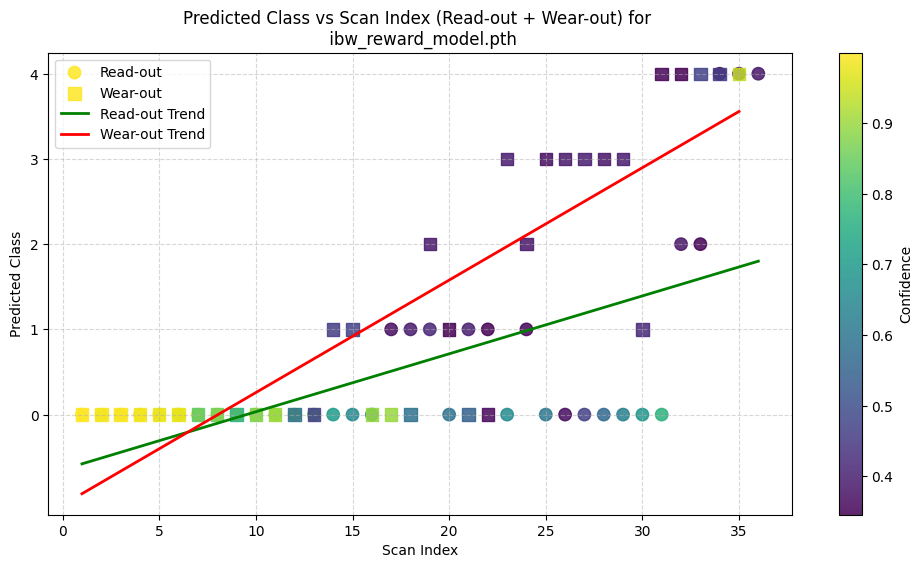

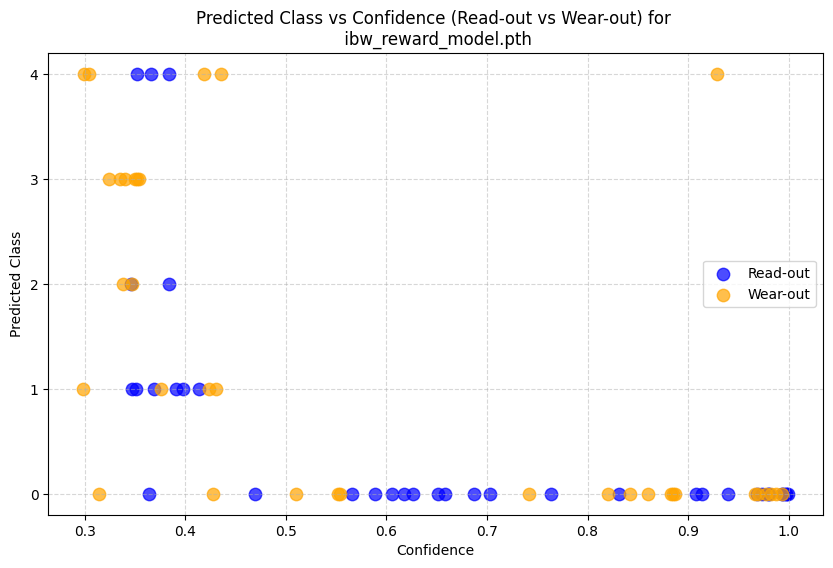

In [143]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = load_trained_model(model_path, device=device) # Change as needed to observe
file = "exp_data/June 18/read_out/Read_out_0000.ibw"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Read-out folder predictions ---
read_out_folder = os.path.dirname(file)
read_out_files = sorted([os.path.join(read_out_folder, f) for f in os.listdir(read_out_folder) if f.lower().endswith(".ibw")])

model_metadata_path = "model_training_metadata.pkl"
results_read = predict_with_training_metadata(model, read_out_files, model_metadata_path, device)

# --- Wear-out folder predictions ---
wear_out_folder = read_out_folder.replace("read_out", "wear_out")
wear_out_files = sorted([os.path.join(wear_out_folder, f) for f in os.listdir(wear_out_folder) if f.lower().endswith(".ibw")])
results_wear = predict_with_training_metadata(model, wear_out_files, model_metadata_path, device)

# --- Combine for plotting ---
import matplotlib.pyplot as plt

# Read-out
scan_indices_read = [r.get('scan_index', r.get('scan_index_used', i + 1)) for i, r in enumerate(results_read)]
predicted_classes_read = [r['predicted_class'] for r in results_read]
confidences_read = [r['confidence'] for r in results_read]

# Wear-out (reset scan index to start from 1)
scan_indices_wear = [i + 1 for i in range(len(results_wear))]
predicted_classes_wear = [r['predicted_class'] for r in results_wear]
confidences_wear = [r['confidence'] for r in results_wear]

# Plot both with confidence as color, wear-out as squares, read-out as circles
import numpy as np

plt.figure(figsize=(12, 6))
# Read-out: circles, color by confidence
scatter1 = plt.scatter(
    scan_indices_read, predicted_classes_read, 
    c=confidences_read, cmap='viridis', s=80, alpha=0.85, label='Read-out', marker='o'
)
# Wear-out: squares, color by confidence
scatter2 = plt.scatter(
    scan_indices_wear, predicted_classes_wear, 
    c=confidences_wear, cmap='viridis', s=80, alpha=0.85, label='Wear-out', marker='s'
)

# Add trendline for read-out
z_read = np.polyfit(scan_indices_read, predicted_classes_read, 1)
p_read = np.poly1d(z_read)
plt.plot(scan_indices_read, p_read(scan_indices_read), color='green', linewidth=2, label='Read-out Trend')

# Add trendline for wear-out
z_wear = np.polyfit(scan_indices_wear, predicted_classes_wear, 1)
p_wear = np.poly1d(z_wear)
plt.plot(scan_indices_wear, p_wear(scan_indices_wear), color='red', linewidth=2, label='Wear-out Trend')

plt.xlabel('Scan Index')
plt.ylabel('Predicted Class')
plt.title(f'Predicted Class vs Scan Index (Read-out + Wear-out) for \n {model_path}')
plt.yticks(range(5), ['0', '1', '2', '3', '4'])
cbar = plt.colorbar(scatter1, label='Confidence', orientation='vertical')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(confidences_read, predicted_classes_read, c='blue', label='Read-out', alpha=0.7, s=80)
plt.scatter(confidences_wear, predicted_classes_wear, c='orange', label='Wear-out', alpha=0.7, s=80)
plt.xlabel('Confidence')
plt.ylabel('Predicted Class')
plt.title(f'Predicted Class vs Confidence (Read-out vs Wear-out) for \n {model_path}')
plt.yticks(range(5), ['0', '1', '2', '3', '4'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


### ROC - AUC Curves


In [144]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np

def add_true_labels_to_results_using_scan_indices(results):
    """
    Extract scan indices from each result's filename and generate
    true labels using your generate_labels_from_scan_indices function.
    
    Args:
        results (list of dict): Each dict has 'file_path'
        
    Returns:
        results (list of dict): Each dict updated with 'true_class'
    """
    # Extract all scan indices first
    scan_indices = []
    for r in results:
        file_path = r.get('file_path', None)
        if file_path is None:
            scan_indices.append(None)
        else:
            scan_indices.append(extract_scan_index_from_filename(file_path))
    
    # Filter out None indices before label generation
    valid_scan_indices = [idx for idx in scan_indices if idx is not None]
    
    # Generate labels only for valid indices
    generated_labels = generate_labels_from_scan_indices(valid_scan_indices)
    
    # Map generated labels back to results (handle None gracefully)
    label_idx = 0
    for i, idx in enumerate(scan_indices):
        if idx is None:
            results[i]['true_class'] = None
        else:
            results[i]['true_class'] = generated_labels[label_idx]
            label_idx += 1
    
    return results


def generate_roc_auc_curve(results, num_classes=5, output_path=None):
    """
    Generate ROC-AUC curves from prediction results
    
    Args:
        results: List of dicts from `predict_single_ibw` or similar
        num_classes: Total number of classes
        output_path: Optional path to save the plot
    
    Returns:
        auc_scores: Dict of AUC scores per class
    """
    results = add_true_labels_to_results_using_scan_indices(results)

    # Then generate ROC curves using 'true_class' instead of 'predicted_class'
    y_true = []
    y_probs = []
    for r in results:
        if r.get('true_class') is not None:
            y_true.append(r['true_class'])
            y_probs.append(r['class_probabilities'])

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    # Binarize labels for one-vs-rest ROC computation
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    
    if output_path:
        plt.savefig(output_path)
        print(f"Saved ROC curve to {output_path}")
    else:
        plt.show()

    return roc_auc


In [145]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from torchvision import transforms

# --- Assumes all the functions you wrote above are already defined:
# - load_trained_model
# - predict_with_training_metadata
# - etc.

def generate_roc_auc_curve(results, num_classes=5, title="ROC Curve", output_path=None):
    """
    Generate and plot the ROC-AUC curve for multiclass classification.
    """
    y_true = []
    y_probs = []

    for r in results:
        if r.get("true_class") is not None:
            y_true.append(r["true_class"])
            y_probs.append(r["class_probabilities"])

    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    # Binarize the output for multiclass ROC
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve
    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)

    if output_path:
        plt.savefig(output_path)
        print(f"ROC curve saved to {output_path}")
    else:
        plt.show()

    return roc_auc

C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded from ibw_reward_model.pth
Predicting quality for 36 files...
Processing file 1/36: exp_data/June 18\read_out\Read_out_0000.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.997 confidence
Processing file 2/36: exp_data/June 18\read_out\Read_out_0001.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.997 confidence
Processing file 3/36: exp_data/June 18\read_out\Read_out_0002.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.999 confidence
Processing file 4/36: exp_data/June 18\read_out\Read_out_0003.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.994 confidence
Processing file 5/36: exp_data/June 18\read_out\Read_out_0004.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.993 confidence
Processing file 6/36: exp_data/June 18\read_out\Read_out_0005.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.968 confidence
Processing file 7/36: exp_data/June 18\read_out\Read_out_0006.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.973 confidence
Processin

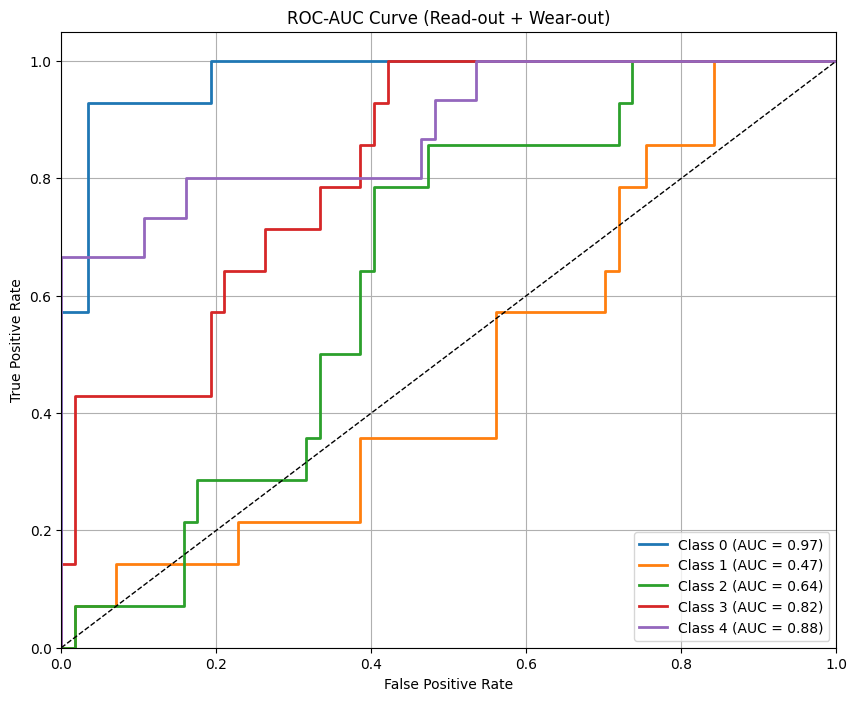


Per-Class AUC Scores:
  Class 0: 0.9737
  Class 1: 0.4749
  Class 2: 0.6429
  Class 3: 0.8233
  Class 4: 0.8833


In [146]:

def inspect_results(results, num_samples=5):
    """
    Inspect a few samples from the results list to understand their structure.

    Prints:
    - Keys available in each result dict
    - True label (if any)
    - Predicted class
    - Class probabilities and their sum

    Args:
        results (list of dict): Your prediction results
        num_samples (int): How many samples to show
    """
    print(f"Total results: {len(results)}")
    print("Inspecting first", num_samples, "samples...\n")

    for i, r in enumerate(results[:num_samples]):
        print(f"Sample #{i + 1}:")
        print("Keys:", list(r.keys()))

        # Try to print true label if exists
        true_label = r.get('true_class') or r.get('label') or r.get('target') or None
        print("True label:", true_label)

        pred_class = r.get('predicted_class')
        print("Predicted class:", pred_class)

        class_probs = r.get('class_probabilities')
        if class_probs is not None:
            print("Class probabilities:", class_probs)
            print("Sum of probabilities:", sum(class_probs))
        else:
            print("Class probabilities: None")

        print("-" * 40)

if __name__ == "__main__": # Configure the files below
    base_folder = "exp_data/June 18"
    metadata_path = "model_training_metadata.pkl"   # Don't need to change
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load model
    model = load_trained_model(model_path, device=device)

    # Define transform (if not embedded in metadata, fallback here)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Get .ibw file lists
    read_out_folder = os.path.join(base_folder, "read_out")
    wear_out_folder = os.path.join(base_folder, "wear_out")

    read_out_files = sorted([
        os.path.join(read_out_folder, f) for f in os.listdir(read_out_folder)
        if f.lower().endswith(".ibw")
    ])
    wear_out_files = sorted([
        os.path.join(wear_out_folder, f) for f in os.listdir(wear_out_folder)
        if f.lower().endswith(".ibw")
    ])


    # # Predict on both datasets
    results_read = predict_with_training_metadata(model, read_out_files, metadata_path, device)
    results_wear = predict_with_training_metadata(model, wear_out_files, metadata_path, device)

    # Combine results and generate ROC curve
    all_results = results_read + results_wear
    all_results = add_true_labels_to_results_using_scan_indices(all_results)

    # inspect_results(all_results)
    roc_auc = generate_roc_auc_curve(all_results, num_classes=5, title="ROC-AUC Curve (Read-out + Wear-out)")

    print("\nPer-Class AUC Scores:")
    for cls, score in roc_auc.items():
        print(f"  Class {cls}: {score:.4f}")


C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded from ibw_reward_model.pth
Found 36 files in exp_data/June 18/read_out
Found 35 files in exp_data/June 18/wear_out
Predicting quality for 71 files...
Processing file 1/71: exp_data/June 18/read_out\Read_out_0000.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.997 confidence
Processing file 2/71: exp_data/June 18/wear_out\Wear_out_0000.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.993 confidence
Processing file 3/71: exp_data/June 18/read_out\Read_out_0001.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.997 confidence
Processing file 4/71: exp_data/June 18/wear_out\Wear_out_0001.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.982 confidence
Processing file 5/71: exp_data/June 18/read_out\Read_out_0002.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.999 confidence
Processing file 6/71: exp_data/June 18/wear_out\Wear_out_0002.ibw
  Predicted: Class 0 (Excellent (Class 0)) with 0.987 confidence
Processing file 7/71: exp_data/June 18/read_out\Read

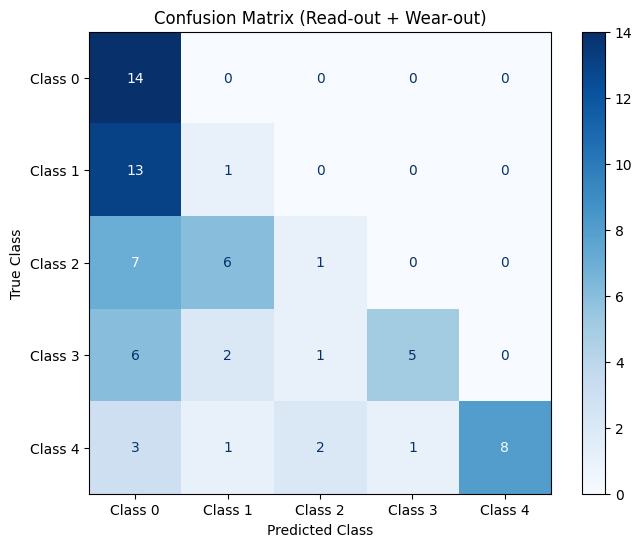

array([[14,  0,  0,  0,  0],
       [13,  1,  0,  0,  0],
       [ 7,  6,  1,  0,  0],
       [ 6,  2,  1,  5,  0],
       [ 3,  1,  2,  1,  8]], dtype=int64)

In [147]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def generate_labels_from_scan_indices(scan_indices):
    sorted_indices = sorted(scan_indices)
    total_samples = len(sorted_indices)
    samples_per_group = total_samples / 5.0
    
    index_to_label = {}
    for i, idx in enumerate(sorted_indices):
        label = min(int(i / samples_per_group), 4)
        index_to_label[idx] = label
    
    labels = [index_to_label[idx] for idx in scan_indices]
    return labels

def get_all_ibw_files(folder, recursive=True):
    """Return a list of all .ibw files in a folder (optionally recursive)"""
    ibw_files = []
    if recursive:
        for root, dirs, files in os.walk(folder):
            for f in files:
                if f.lower().endswith('.ibw'):
                    ibw_files.append(os.path.join(root, f))
    else:
        ibw_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith('.ibw')]
    return ibw_files

def compute_confusion_matrix_from_multiple_folders(parent_folder, subfolders, model, transform, num_classes=5, title="Confusion Matrix"):
    """
    Reads .ibw files from multiple subfolders, predicts classes, and plots the confusion matrix.
    True classes are assigned by splitting scan indices into equal groups.
    """
    all_files = []
    for sub in subfolders:
        folder_path = os.path.join(parent_folder, sub)
        files = get_all_ibw_files(folder_path)
        print(f"Found {len(files)} files in {folder_path}")
        all_files.extend(files)

    if not all_files:
        print(f"No .ibw files found in specified folders: {subfolders}")
        return None

    scan_indices = [extract_scan_index_from_filename(f) for f in all_files]
    
    # Sort files and scan indices together
    sorted_pairs = sorted(zip(scan_indices, all_files), key=lambda x: x[0])
    sorted_scan_indices, sorted_files = zip(*sorted_pairs)
    total_files = len(sorted_files)

    # True classes
    true_classes = generate_labels_from_scan_indices(sorted_scan_indices)

    # Predict classes
    predicted_classes = []

    results = predict_with_training_metadata(
        model, list(sorted_files), model_metadata_path, device='cuda' if torch.cuda.is_available() else 'cpu'
    )
    predicted_classes = [r['predicted_class'] for r in results]
    

    # Ensure integer dtype
    true_classes = np.array(true_classes, dtype=int)
    predicted_classes = np.array(predicted_classes, dtype=int)

    print("Unique true labels:", np.unique(true_classes))
    print("Unique predicted labels:", np.unique(predicted_classes))


    # Confusion Matrix
    cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(num_classes)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Class {i}" for i in range(num_classes)])
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.show()
    return cm

# Example usage:
device = "cuda" if torch.cuda.is_available() else "cpu"
# Make sure model_path is a string and transform is a Compose object
model = load_trained_model(model_path, device=device)
compute_confusion_matrix_from_multiple_folders(
    parent_folder="exp_data/June 18/",
    subfolders=["read_out", "wear_out"],
    model=model,
    transform=transform,
    num_classes=5,
    title="Confusion Matrix (Read-out + Wear-out)"
)